In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf 
from pathlib import Path

import what_where as ww

In [9]:
cfg_main = ww.utils.load_config(f"config_vcs_fixed")


In [10]:

dataset_path = ww.utils.DATA_DIR / "behavioral_datasets" / "behavioral_experiment"
dataset_df = ww.utils.load_dataset_df(dataset_path / "behavioral_dataset.csv")
model_summary_df = ww.utils.get_model_summary_df(ww.utils.load_model_df(cfg_main, dataset_df))

# finding the energy cost for each model that achieves at least 32% accuracy in what (cfg.plotting.model_results.what_accuracy_threshold_for_energy_breakdown: 0.32)
model_acc_by_energy_cost = model_summary_df.groupby(['model', 'energy_cost'])['what_correct_last'].mean().reset_index()
print(model_acc_by_energy_cost)

# find the min energy cost that achieves at least 32% accuracy for each model
threshold = cfg_main.plotting.model_results.what_accuracy_threshold_for_energy_breakdown
models_above_threshold = model_acc_by_energy_cost[model_acc_by_energy_cost['what_correct_last'] >= threshold]
max_energy_costs = models_above_threshold.groupby('model')['energy_cost'].max().reset_index()
max_energy_costs


loading model data for journal_fixed
320000 rows in model dataframe before filtering
['ean_global' 'ean_full' 'ean_space' 'baseline' 'ean_features']
320000 rows in model dataframe when returning

getting model summary dataframe...
           model  energy_cost  what_correct_last
0       baseline        -12.0             0.4910
1       baseline        -11.0             0.4920
2       baseline        -10.0             0.4880
3       baseline         -9.0             0.4525
4       baseline         -8.0             0.3625
5       baseline         -7.0             0.2750
6       baseline         -6.0             0.2255
7       baseline         -5.0             0.2190
8   ean_features        -12.0             0.6450
9   ean_features        -11.0             0.6590
10  ean_features        -10.0             0.6325
11  ean_features         -9.0             0.6100
12  ean_features         -8.0             0.5515
13  ean_features         -7.0             0.4645
14  ean_features         -6.0     

,model,energy_cost
0,baseline,-9.0
1,ean_features,-7.0
2,ean_full,-7.0
3,ean_global,-11.0
4,ean_space,-7.0


cuda:0 torch.Size([400, 1, 64, 64])
tensor(-0.5004, device='cuda:0') tensor(0.5288, device='cuda:0')


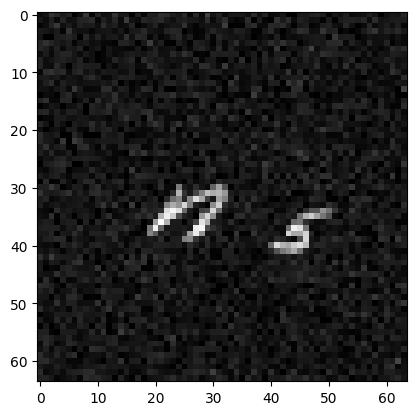

In [11]:
# load images as pytorch tensors from png
def load_image(image_path):
    image = plt.imread(image_path)
    image = torch.from_numpy(image)
    image = image.unsqueeze(0)
    return image

images = []
for i in range(dataset_df.shape[0]):
    image_path = dataset_path / "images" / f"image_{i}.png"
    image = load_image(image_path)
    images.append(image)

images = torch.cat(images, dim=0)
images = images.unsqueeze(1) # add chanel dimension
images = images.to("cuda")
transform = ww.utils.get_transforms(cfg_main)[1] # only validation transform
for i in range(images.shape[0]):
    images[i] = transform(images[i])

print(images.device, images.shape)
# show some images
plt.imshow(images[0].squeeze().cpu().numpy(), cmap="gray")
print(images[0].mean(), images[0].std())

In [12]:
def get_energy_use_breakdown(out):
    energies = {}

    for t in range(len(out)):
        for energy_type in ["activations", "synaptic_transmission"]:
            for layer_name in out[t][energy_type].keys():
                key = f"{t}_{layer_name}_{energy_type}"
                value = out[t][energy_type][layer_name]

                if value.dim() > 1:
                    dim = tuple(range(1, value.dim()))
                    value = value.sum(dim=dim).mean()  # sum non-batch dims, then mean over batch
                else:
                    value = value.mean()  # just mean over batch if already 1D


                if energy_type == "activations":
                    value *= cfg_main.train.energy.ap_scale
                elif energy_type == "synaptic_transmission":
                    value *= cfg_main.train.energy.st_scale

                energies[key] = value.item()

    energy_use_breakdown = {
        "cnn" : sum([v for k, v in energies.items() if "conv" in k]),
        "rnn" : sum([v for k, v in energies.items() if "rnn" in k]),
        "gain" : sum([v for k, v in energies.items() if "gain" in k]),
    }

    return energy_use_breakdown


In [15]:
# collect data for 

path = Path("energy_use_per_component_vcs_fixed.csv")
print(path)
if path.exists():
    energy_use_df = pd.read_csv(path)
    print("Loaded existing energy use breakdown data:")
    print(energy_use_df.head())
else:
    data = {
        "model" : [],
        "instance" : [],
        "energy_cost" : [],
        "cnn_energy_use" : [],
        "rnn_energy_use" : [],
        "gain_energy_use" : [],
        "accuracy" : [],
    }


    device = 'cuda'

    for model_name in max_energy_costs['model']:
        energy_cost = max_energy_costs[max_energy_costs['model'] == model_name]['energy_cost'].values[0]

        for instance in range(5):
            print(f"Processing model: {model_name} at energy cost: {energy_cost}, instance: {instance}")

            # creating a config to load the checkpoint
            cfg_ = cfg_main.copy()
            cfg_.model.name = model_name
            cfg_.train.instance = instance
            cfg_.train.energy.cost.min = float(energy_cost)
            checkpoint_path = ww.utils.get_checkpoint_path(cfg_)
            checkpoint = torch.load(checkpoint_path, weights_only=False)

            # loading the actual config used for this model with the correct gain mechanisms, etc.
            cfg = OmegaConf.create(checkpoint["config"])
            cfg.train.energy.st_sample_ratio = 1.0 # full energy use estimate without stochastic sampling

            model = ww.model.Model(cfg)
            model.to(device)
            model.load_state_dict(checkpoint["model_state_dict"])
            model.eval()

            with torch.no_grad():
                energy_cost_batch = torch.tensor(energy_cost, dtype=torch.float32).to(device).repeat(len(images), 1)
                out = model(images, energy_cost_batch, cfg.model.n_passes, noise_anneal=1.0)

                # energy_use = model.energy_estimator.get_energy_use_breakdown()

                data["model"].append(model_name)
                data["instance"].append(instance)
                data["energy_cost"].append(energy_cost)
                energy_use_breakdown = get_energy_use_breakdown(out)
                data["cnn_energy_use"].append(energy_use_breakdown["cnn"])
                data["rnn_energy_use"].append(energy_use_breakdown["rnn"])
                data["gain_energy_use"].append(energy_use_breakdown["gain"])
                accuracy = (out[cfg.model.n_passes-1]["prediction"]["what"].argmax(dim=1).cpu() == dataset_df['what'].values).float().mean().item()
                data["accuracy"].append(accuracy)

    energy_use_df = pd.DataFrame(data)
    energy_use_df.to_csv(path, index=False)

energy_use_per_component_vcs_fixed.csv
Loaded existing energy use breakdown data:
      model  instance  energy_cost  cnn_energy_use  rnn_energy_use  \
0  baseline         0         -9.0    30569.066010     1124.101115   
1  baseline         1         -9.0    30792.999039     1137.113797   
2  baseline         2         -9.0    30819.157990     1119.429040   
3  baseline         3         -9.0    30727.739044     1104.038658   
4  baseline         4         -9.0    30752.840988     1135.962620   

   gain_energy_use  accuracy  
0              0.0    0.4625  
1              0.0    0.4275  
2              0.0    0.4500  
3              0.0    0.4525  
4              0.0    0.4425  


In [16]:
energy_use_df["log_energy_use"] = np.log(energy_use_df["cnn_energy_use"] + energy_use_df["rnn_energy_use"] + energy_use_df["gain_energy_use"])
energy_use_df

,model,instance,energy_cost,cnn_energy_use,rnn_energy_use,gain_energy_use,accuracy,log_energy_use
0,baseline,0,-9.0,30569.066010,1124.101115,0.000000,0.4625,10.363856
1,baseline,1,-9.0,30792.999039,1137.113797,0.000000,0.4275,10.371305
2,baseline,2,-9.0,30819.157990,1119.429040,0.000000,0.4500,10.371570
3,baseline,3,-9.0,30727.739044,1104.038658,0.000000,0.4525,10.368220
4,baseline,4,-9.0,30752.840988,1135.962620,0.000000,0.4425,10.370010
5,ean_features,0,-7.0,16636.082550,525.117933,50.270758,0.4525,9.753331
6,ean_features,1,-7.0,16726.439697,500.807356,64.620539,0.4575,9.757992
7,ean_features,2,-7.0,16694.102158,505.022957,63.098363,0.4325,9.756276
8,ean_features,3,-7.0,16731.020386,496.575007,66.879833,0.4825,9.758142
9,ean_features,4,-7.0,16739.072319,509.937475,66.166819,0.4500,9.759339


In [42]:
# calculate the upper bound of gain application cost that would still bring net energetic benefits
# baseline vs. ean_full

energy_use_df["non_cnn_energy_use"] = energy_use_df["rnn_energy_use"] + energy_use_df["gain_energy_use"]
energy_use_df["energy_use"] = np.exp(energy_use_df["log_energy_use"])
net_benefit = energy_use_df[energy_use_df["model"] == "baseline"]["energy_use"].mean() - energy_use_df[energy_use_df["model"] == "ean_full"]["energy_use"].mean()
ean_full_non_cnn_energy_use = energy_use_df[energy_use_df["model"] == "ean_full"]["non_cnn_energy_use"].mean()

print(net_benefit)
# print(f"Net energetic benefit: {net_benefit:.2f}")
print(f"This is how many times the gain associated costs could be increased and still be worth it: {net_benefit / ean_full_non_cnn_energy_use:.2f}")

print("mean accuracy for baseline model: ", energy_use_df[energy_use_df["model"] == "baseline"]["accuracy"].mean())
print("mean accuracy for ean_full model: ", energy_use_df[energy_use_df["model"] == "ean_full"]["accuracy"].mean())


13859.099448006822
This is how many times the gain associated costs could be increased and still be worth it: 19.09
mean accuracy for baseline model:  0.44699999690055847
mean accuracy for ean_full model:  0.5379999995231628
